# Mesh Adaptive Direct Search (MADS)

Este notebook tem como objetivo implementar o algoritmo de otimização *derivate-free* MADS para encontrar o mínimo de uma função clássica, a fim de permitir futuros *benchmarkings*.

**Autor:** Edélio Gabriel Magalhães de Jesus.

## Introdução

O MADS (*Mesh Adaptive Direct Search*) é um algoritmo de otimização direta para funções contínuas de caixa-preta, proposto por Charles Audet e John E. Dennis Jr. em meados da década de 2000. Ele pertence à família dos métodos de busca direta (*direct search methods*), que não utilizam derivadas, sendo especialmente adequado para problemas onde a função objetivo é não-diferenciável, descontínua, ruidosa ou extremamente cara de avaliar.

### A ideia central

O algoritmo mantém uma **malha (*mesh*)** discreta no espaço de busca, que é refinada ou expandida dinamicamente conforme a exploração avança. A cada iteração, o MADS executa duas etapas principais:

1. **Busca (*search*)**: etapa opcional e flexível que pode utilizar qualquer estratégia heurística (como busca aleatória, polling, ou até mesmo outros algoritmos) para explorar pontos promissores na malha.
2. **Polling (*poll*)**: etapa obrigatória que avalia sistematicamente um conjunto de direções ao redor do ponto atual, formando um padrão (*pattern*) que garante convergência teórica.

### O mecanismo da malha

A malha é definida como um conjunto discreto de pontos:

$$M_k = \{ x_k + \Delta_k^m D z : z \in \mathbb{N}^{n_D} \}$$

onde $x_k$ é o ponto central atual, $\Delta_k^m$ é o tamanho da malha (*mesh size*), $D$ é uma matriz de direções geradoras e $n_D$ é o número dessas direções. O parâmetro $\Delta_k^p$ (tamanho do poll) controla a distância dos pontos avaliados no polling.

A cada iteração:

- **Se um ponto melhor é encontrado**: o algoritmo mantém ou expande a malha, movendo o ponto central para a nova solução.
- **Se nenhum ponto melhor é encontrado**: a malha é refinada (tamanho reduzido), concentrando a busca na vizinhança do ponto atual.

### Adaptação da malha

O MADS utiliza dois parâmetros de tamanho distintos:

- **Tamanho da malha ($\Delta_k^m$)**: controla a densidade da malha. Diminui quando o polling falha em encontrar melhores pontos.
- **Tamanho do poll ($\Delta_k^p$)**: controla a distância dos pontos avaliados no polling. É sempre $\Delta_k^p \geq \Delta_k^m$, permitindo que a busca explore tanto finamente quanto mais amplamente.

A atualização segue a regra:

$$x_{k+1} = 
\begin{cases} 
x_k + d_k & \text{se } f(x_k + d_k) < f(x_k) \text{ para algum } d_k \in P_k \\
x_k & \text{caso contrário}
\end{cases}
$$

onde $P_k$ é o conjunto de direções de polling. O tamanho da malha é então atualizado como:

$$\Delta_{k+1}^m = 
\begin{cases} 
\tau \Delta_k^m & \text{se sucesso (expansão)} \\
\Delta_k^m / \tau & \text{se falha (refinamento)}
\end{cases}
$$

com $\tau > 1$ tipicamente igual a 2 ou 4.

### Direções e padrões

O MADS se diferencia de métodos anteriores (como o GPS - *Generalized Pattern Search*) por permitir um conjunto mais rico de direções:

- **Direções finas (*refining directions*)**: garantem que o polling pode se concentrar em direções específicas quando a malha é refinada.
- **Direções ricas (*rich directions*)**: permitem que o polling avalie pontos em direções que não estão necessariamente alinhadas com a base canônica.

Na prática, o MADS gera direções como:

$$D_k = \left[ \begin{array}{cccc} 
1 & 0 & \cdots & 0 \\
-1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
0 & -1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1 \\
0 & 0 & \cdots & -1 
\end{array} \right] \cdot \Delta_k^p + \text{direções extras}$$

Para problemas com restrições, o MADS incorpora mecanismos adicionais como **barreiras progressivas (*progressive barrier*)** e **extremos (*extreme barrier*)**, que tratam pontos inviáveis de forma diferenciada.

### Complexidade e limitações

O MADS é computacionalmente leve em cada iteração: o custo dominante é a avaliação da função objetivo nos pontos do polling, que normalmente é $O(2n)$ ou $O(4n)$ por iteração, onde $n$ é a dimensão do problema. O algoritmo não requer armazenamento de matrizes ou histórico extenso, tornando-o adequado para problemas de alta dimensão (centenas ou milhares de variáveis) desde que o orçamento de avaliações seja controlado.

**Principais limitações:**

- Convergência mais lenta em problemas bem-comportados comparado a métodos baseados em gradiente
- Sensibilidade à escolha dos parâmetros iniciais ($\Delta^m$, $\Delta^p$, $\tau$)
- O desempenho degrada em superfícies extremamente mal-condicionadas, onde a adaptação da malha pode ser insuficiente
- A etapa opcional de *search* pode exigir ajustes específicos para cada problema

### Variações e extensões

- **Ortho-MADS**: utiliza direções ortonormais geradas a partir de matrizes de Hadamard ou Householder, garantindo melhor exploração do espaço de busca.
- **LTMADS (*LTM ADS*)**: variante que utiliza um número reduzido de direções para problemas de alta dimensão.
- **Multiobjetivo MADS**: extensão para problemas com múltiplas funções objetivo, mantendo uma frente de Pareto.
- **MADS com busca Bayesian**: incorpora modelos substitutos (*surrogate models*) para reduzir o número de avaliações caras.

## Função de *baseline*

### **Ackley Function**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/ackley.png" alt="Função de Ackley" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from mads import mads
import time

In [87]:
def ackley(x):
    x = np.array(x)
    n = len(x)
    return (
        -20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n))
        - np.exp(np.sum(np.cos(2 * np.pi * x)) / n)
        + 20 + np.e
    )

## Função para o MADS (PyPI)

In [101]:
def run_mads(dim, budget, seed):
    np.random.seed(seed)
    
    # Ponto inicial aleatório
    x0 = np.random.uniform(-5, 5, dim)
    
    # Limites
    bounds_lower = np.array([-5] * dim)
    bounds_upper = np.array([5] * dim)
    
    # Parâmetros
    dp = 1.0
    dm = 0.0
    dp_tol = 1e-12
    nitermax = budget
    displog = 0
    savelog = 0
    
    t0 = time.time()
    res = mads.orthomads(
        x0, bounds_upper, bounds_lower, ackley,
        dp, dm, dp_tol, nitermax, displog, savelog
    )
    t1 = time.time()
    
    # Extrair o valor da função d
    if isinstance(res, (list, tuple)):
        if len(res) >= 2:
            f_best = res[1]
        else:
            f_best = res[0]
    else:
        f_best = res
    
    # Converter para escalar se for array
    if isinstance(f_best, np.ndarray):
        f_best = f_best.item() if f_best.size == 1 else float(f_best[0])
    
    return float(f_best), t1 - t0

## Avaliando

Executando MADS...
Rodada 1/100... 

c:\Users\edelio25024\OneDrive - ILUM ESCOLA DE CIÊNCIA\MATERIAIS_ILUM\IP II - BLACK BOX\CODES\.venv\Lib\site-packages\mads\mads.py:30: RuntimeWarning: divide by zero encountered in divide
  points = np.round((points + 1) / 2 / ratio) * ratio * 2 - 1
c:\Users\edelio25024\OneDrive - ILUM ESCOLA DE CIÊNCIA\MATERIAIS_ILUM\IP II - BLACK BOX\CODES\.venv\Lib\site-packages\mads\mads.py:30: RuntimeWarning: invalid value encountered in divide
  points = np.round((points + 1) / 2 / ratio) * ratio * 2 - 1
c:\Users\edelio25024\OneDrive - ILUM ESCOLA DE CIÊNCIA\MATERIAIS_ILUM\IP II - BLACK BOX\CODES\.venv\Lib\site-packages\mads\mads.py:30: RuntimeWarning: invalid value encountered in multiply
  points = np.round((points + 1) / 2 / ratio) * ratio * 2 - 1


OK - f(x) = 0.48813504, tempo = 7.18s
Rodada 2/100... OK - f(x) = -0.82977995, tempo = 7.08s
Rodada 3/100... OK - f(x) = -0.64005098, tempo = 6.86s
Rodada 4/100... OK - f(x) = 0.50797903, tempo = 7.80s
Rodada 5/100... OK - f(x) = 4.67029839, tempo = 8.47s
Rodada 6/100... OK - f(x) = -2.78006829, tempo = 6.75s
Rodada 7/100... OK - f(x) = 3.92860151, tempo = 7.33s
Rodada 8/100... OK - f(x) = -4.23691711, tempo = 18.52s
Rodada 9/100... OK - f(x) = 3.73429403, tempo = 15.19s
Rodada 10/100... OK - f(x) = -4.89625846, tempo = 18.68s
Rodada 11/100... OK - f(x) = 2.71320643, tempo = 8.49s
Rodada 12/100... OK - f(x) = -3.19730311, tempo = 5.44s
Rodada 13/100... OK - f(x) = -3.45837158, tempo = 6.30s
Rodada 14/100... OK - f(x) = 2.77702411, tempo = 5.83s
Rodada 15/100... OK - f(x) = 0.13943344, tempo = 5.91s
Rodada 16/100... OK - f(x) = 3.48817697, tempo = 7.43s
Rodada 17/100... OK - f(x) = -2.76708921, tempo = 7.31s
Rodada 18/100... OK - f(x) = -2.05334997, tempo = 8.83s
Rodada 19/100... OK - f

C:\Users\edelio25024\AppData\Local\Temp\ipykernel_23888\2005178622.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([final_values.tolist()], labels=['MADS'], patch_artist=True)


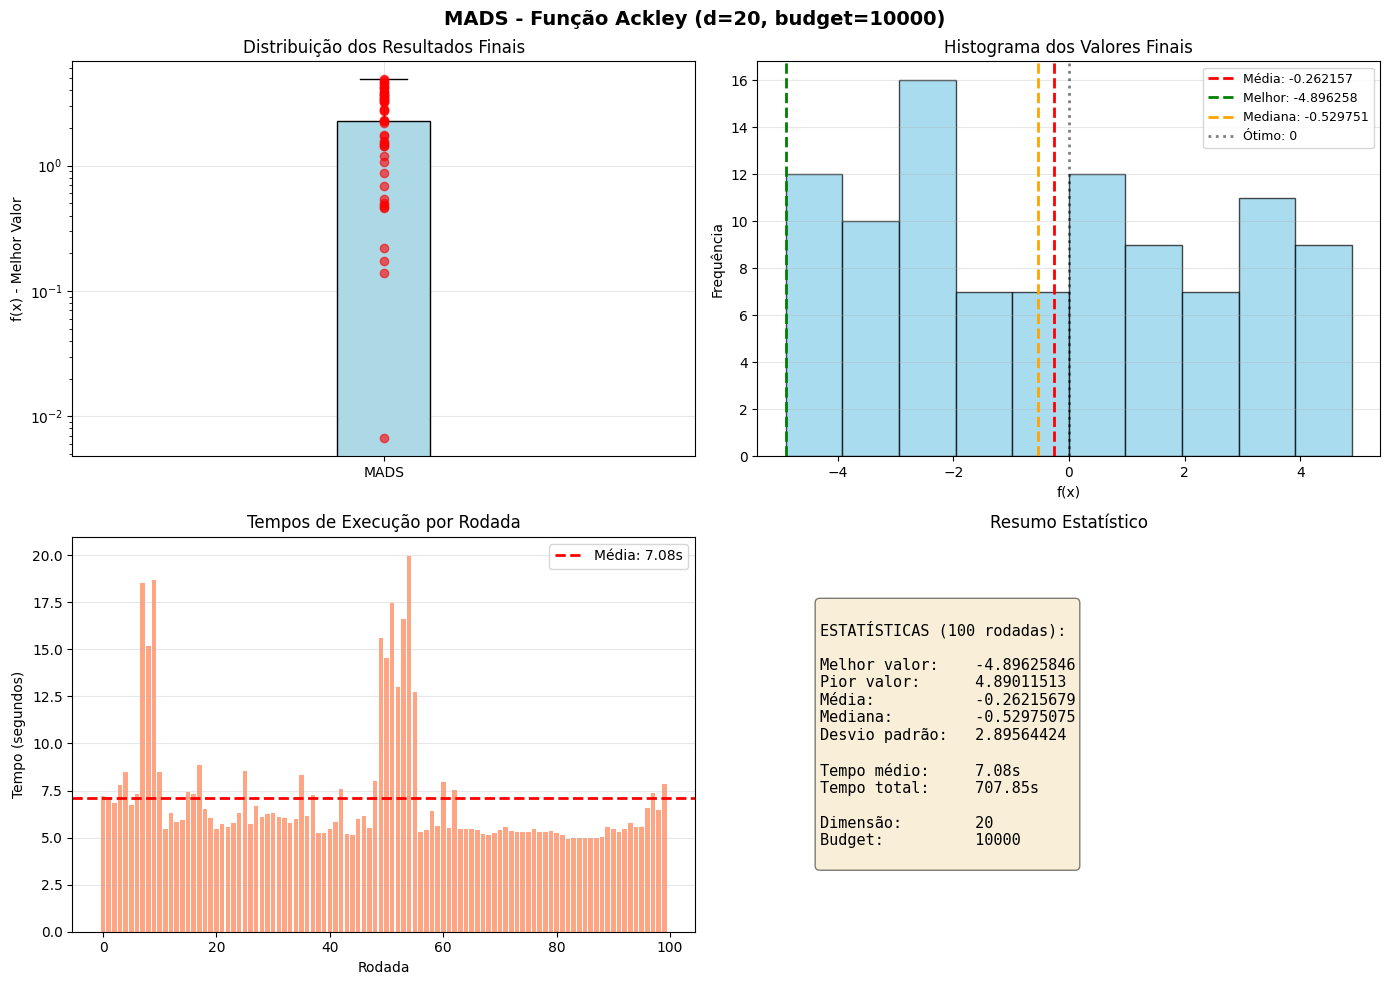


RESUMO DA EXECUÇÃO - MADS na função Ackley (d=20)
Execuções bem-sucedidas: 100/100
Budget por rodada:       10000 avaliações
Melhor resultado:        -4.8962584611
Pior resultado:          4.8901151348
Média:                   -0.2621567880
Mediana:                 -0.5297507482
Desvio padrão:           2.8956442441
Tempo médio por rodada:  7.08 segundos
Tempo total:             707.85 segundos
Valor ótimo teórico:     0.0

Taxa de sucesso (|f| < 1e-06): 0.0%

Resultados individuais:
  ○ Rodada  1: f(x) = 0.48813504  |  tempo = 7.18s
  ○ Rodada  2: f(x) = -0.82977995  |  tempo = 7.08s
  ○ Rodada  3: f(x) = -0.64005098  |  tempo = 6.86s
  ○ Rodada  4: f(x) = 0.50797903  |  tempo = 7.80s
  ○ Rodada  5: f(x) = 4.67029839  |  tempo = 8.47s
  ○ Rodada  6: f(x) = -2.78006829  |  tempo = 6.75s
  ○ Rodada  7: f(x) = 3.92860151  |  tempo = 7.33s
  ○ Rodada  8: f(x) = -4.23691711  |  tempo = 18.52s
  ○ Rodada  9: f(x) = 3.73429403  |  tempo = 15.19s
  ○ Rodada 10: f(x) = -4.89625846  |  tempo =

In [102]:
# Parâmetros
dim = 20
budget = 10000
n_runs = 100

# Executar múltiplas rodadas
hist_mads = []
times_mads = []

print("Executando MADS...")
print("="*60)

for i in range(n_runs):
    print(f"Rodada {i+1}/{n_runs}", end="... ")
    try:
        f_best, exec_time = run_mads(dim, budget, i)
        hist_mads.append(f_best)
        times_mads.append(exec_time)
        print(f"OK - f(x) = {f_best:.8f}, tempo = {exec_time:.2f}s")
    except Exception as e:
        print(f"ERRO: {e}")
        # Tentativa de diagnóstico
        print(f"  Tentando diagnóstico...")
        try:
            # Teste com budget pequeno
            test_res = mads.orthomads(
                np.zeros(dim), np.array([5]*dim), np.array([-5]*dim), ackley,
                1.0, 0.0, 1e-12, 10, 0, 0
            )
            print(f"  Tipo do retorno: {type(test_res)}")
            print(f"  Conteúdo: {test_res}")
        except Exception as e2:
            print(f"  Diagnóstico falhou: {e2}")

print("="*60)
print(f"Execuções bem-sucedidas: {len(hist_mads)}/{n_runs}")

if len(hist_mads) == 0:
    print("\nNenhuma execução bem-sucedida!")
    print("Verifique a instalação do pacote 'mads' ou a sintaxe da função.")
    exit()

# Converter para array numpy 
final_values = np.array(hist_mads)

# Estatísticas
best_final = np.min(final_values)
worst_final = np.max(final_values)
mean_final = np.mean(final_values)
std_final = np.std(final_values)
median_final = np.median(final_values)

# =========================
# PLOTS
# =========================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot
bp = ax1.boxplot([final_values.tolist()], labels=['MADS'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax1.set_yscale('log')
ax1.set_ylabel('f(x) - Melhor Valor')
ax1.set_title('Distribuição dos Resultados Finais')
ax1.grid(True, alpha=0.3)

# Adicionar pontos
for val in final_values:
    ax1.scatter(1, val, color='red', alpha=0.6, zorder=3)

# Histograma
ax2.hist(final_values, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
ax2.axvline(mean_final, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_final:.6f}')
ax2.axvline(best_final, color='green', linestyle='--', linewidth=2, label=f'Melhor: {best_final:.6f}')
ax2.axvline(median_final, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {median_final:.6f}')
ax2.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=2, label='Ótimo: 0')
ax2.set_xlabel('f(x)')
ax2.set_ylabel('Frequência')
ax2.set_title('Histograma dos Valores Finais')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Tempos de execução
ax3.bar(range(len(times_mads)), times_mads, color='coral', alpha=0.7)
ax3.axhline(np.mean(times_mads), color='red', linestyle='--', linewidth=2, 
            label=f'Média: {np.mean(times_mads):.2f}s')
ax3.set_xlabel('Rodada')
ax3.set_ylabel('Tempo (segundos)')
ax3.set_title('Tempos de Execução por Rodada')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Resumo estatístico
stats_text = f"""
ESTATÍSTICAS ({len(final_values)} rodadas):

Melhor valor:    {best_final:.8f}
Pior valor:      {worst_final:.8f}
Média:           {mean_final:.8f}
Mediana:         {median_final:.8f}
Desvio padrão:   {std_final:.8f}

Tempo médio:     {np.mean(times_mads):.2f}s
Tempo total:     {np.sum(times_mads):.2f}s

Dimensão:        {dim}
Budget:          {budget}
"""
ax4.text(0.1, 0.5, stats_text, transform=ax4.transAxes, 
         fontsize=11, verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax4.set_title('Resumo Estatístico')
ax4.axis('off')

plt.suptitle(f'MADS - Função Ackley (d={dim}, budget={budget})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================
# RESULTADOS NO CONSOLE
# =========================
print("\n" + "="*70)
print(f"RESUMO DA EXECUÇÃO - MADS na função Ackley (d={dim})")
print("="*70)
print(f"Execuções bem-sucedidas: {len(final_values)}/{n_runs}")
print(f"Budget por rodada:       {budget} avaliações")
print(f"Melhor resultado:        {best_final:.10f}")
print(f"Pior resultado:          {worst_final:.10f}")
print(f"Média:                   {mean_final:.10f}")
print(f"Mediana:                 {median_final:.10f}")
print(f"Desvio padrão:           {std_final:.10f}")
print(f"Tempo médio por rodada:  {np.mean(times_mads):.2f} segundos")
print(f"Tempo total:             {np.sum(times_mads):.2f} segundos")
print(f"Valor ótimo teórico:     0.0")
print("="*70)

# Taxa de sucesso
tolerance = 1e-6
success_rate = np.sum(np.abs(final_values) < tolerance) / len(final_values) * 100
print(f"\nTaxa de sucesso (|f| < {tolerance}): {success_rate:.1f}%")

print("="*70)

# Mostrar resultados individuais
print("\nResultados individuais:")
for i, (val, t) in enumerate(zip(hist_mads, times_mads)):
    status = "✓" if np.abs(val) < 1e-6 else "○"
    print(f"  {status} Rodada {i+1:2d}: f(x) = {val:.8f}  |  tempo = {t:.2f}s")
print("="*70)